In [ ]:
import numpy as np
import scipy
import builtins
_print = builtins.print

def print(*args, **kwargs):
    def colorize(arg):
        if isinstance(arg, (bool, np.bool_)):
            if arg:  # True
                return f'\033[94m{arg}\033[0m'  # Bleu
            else:    # False
                return f'\033[91m{arg}\033[0m'  # Rouge
        return arg
    
    args = [colorize(arg) for arg in args]
    _print(*args, **kwargs)

builtins.print = print

from mes_packages import *

# Définition des coefficients physique
$$
i \omega F_0 Y(x) + M_2(x) Y(x) +  F_x \partial_x  Y(x) + F_y \partial_y  Y(x) = 0
$$


In [ ]:
PRINT = 0
ordre = 2
chi=4.0
rho=0.5
N_hyperbo = 3 # Taille de la matrice du système de Friedrichs et de la variable inconnue
# Definition des matrices du système de Friedrichs
Fx = np.array([[0, 1, 0],
               [1, 0, 0],
                [0, 0, 0]])
Fy = np.array([[0, 0, 1],
                [0, 0, 0],
                [1, 0, 0]])
F0 = np.array([[chi, 0, 0],
                [0, rho, 0],
                [0, 0, rho]])
# Définition de la matrice de flux hyperbolique F(n) = n_x * F_x + n_y * F_y
def defFn(n,Fx=Fx,Fy=Fy):
    n_x, n_y = n
    return n_x * Fx + n_y * Fy  
# Calcul des valeurs et vecteurs propres de la matrice de flux hyperbolique F(n)
def eigen_decomposition_F(n,Fx=Fx,Fy=Fy,F0=F0):
    Fn = defFn(n,Fx=Fx,Fy=Fy)
    values, vectors = scipy.linalg.eigh(Fn, F0)
    return values, vectors

# Test de la décmposition en valeurs propres
n = (1, 1) / np.sqrt(2)
values, vectors = eigen_decomposition_F(n)
if PRINT==1:
    print("Valeurs propres de F(n) : ", values)
    print("Vecteurs propres de F(n) : \n", vectors)
verif = np.linalg.norm(defFn(n)-F0@vectors @ np.diag(values)@vectors.T@F0)<1e-10
print("test de la décompostion aux vp généralisés : ", verif)

# Vérification de l'orthogonalité des vecteurs propres par rapport à la forme sesquilinéaire définie par F0
MATDIAG = vectors.T  @ F0 @ vectors
hors_diag = MATDIAG[~np.eye(N_hyperbo, dtype=bool)]
est_diagonale = np.allclose(hors_diag, 0)
print('La matrice est diagonale :',est_diagonale)



# Calcul des matrices Fplus(n) et Fmoins(n)
def Fplus_Fmoins(n):
    values, vectors = eigen_decomposition_F(n)
    D_plus = np.diag(np.maximum(values, 0))
    D_minus = np.diag(np.minimum(values, 0))
    F_plus = F0@vectors @ D_plus @ vectors.T@F0
    F_minus = F0@vectors @ D_minus @ vectors.T@F0
    return F_plus, F_minus

Fplus, Fmoins = Fplus_Fmoins(n)
if PRINT==1:
    print("Matrice Fplus(n) : \n", Fplus)
    print("Matrice Fmoins(n) : \n", Fmoins)
verification = (np.linalg.norm(defFn(n) - (Fplus + Fmoins))<1e-10)
print('Vérification : F(n) = Fplus(n) + Fmoins(n) : ',verification )



test de la décompostion aux vp généralisés :  True
La matrice est diagonale : True
Vérification : F(n) = Fplus(n) + Fmoins(n) :  True


# Construction du maillage


=== Vérification de l'orientation des triangles ===
Nombre total de triangles: 251

Nombre de triangles corrigés: 0/251
Tous les triangles étaient déjà correctement orientés True

=== Vérification de l'orientation des triangles ===
Nombre total de triangles: 251

Nombre de triangles corrigés: 0/251
Tous les triangles étaient déjà correctement orientés True
Aire min : 0.0001516034395061499
Aire max : 0.00035365087391507605
Aires < tol : 0
Tous les triangles ont une aire strictement positive True
Nombre d'éléments : 251
Nombre de sommets : 164


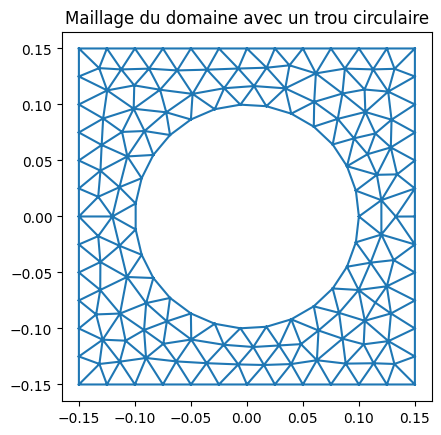

Nombre de triangles : 251
Nombre d'arêtes : 414
Nombre d'arêtes de bord : 75
Table de voisinage correcte True


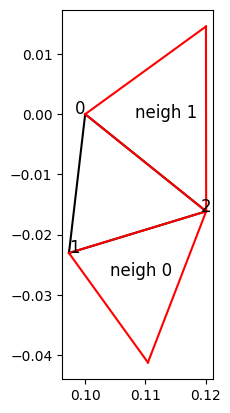

In [ ]:
mesh = create_mesh_circle_in_square(radius=0.1, square_size=0.3, mesh_size=0.025)
# Recuperation de la géométrie du maillage
points = mesh.points[:, :2]  # On ne garde que les coordonnées x et y
triangles = np.asarray(mesh.cells_dict["triangle"]) # mesh.cells_dict["triangle"]
nb_corriges = verifier_et_corriger_orientation(mesh)
# Vérification que les triangles ne sont pas dégénrés
areas,bad=check_triangle_areas(points, triangles, tol=1e-12)
if len(bad) == 0:
    print("Tous les triangles ont une aire strictement positive",True)
else:
    print("Tous les triangles ont une aire strictement positive",False)
# Visualisation du maillage
plot_mesh(mesh)

# Construction de la structure de voisinage
neighbors, neighbor_faces, edges_to_triangles = build_neighborhood_structure(triangles)

print(f"Nombre de triangles : {len(triangles)}")
print(f"Nombre d'arêtes : {len(edges_to_triangles)}")

# Compter les arêtes de bord
n_boundary_edges = sum(1 for edge_list in edges_to_triangles.values() if len(edge_list) == 1)
print(f"Nombre d'arêtes de bord : {n_boundary_edges}")
# Test de la table de voisinage
voisinage_reciproque(neighbors,triangles)
plot_un_trianlge_et_ses_voisins(points, triangles, neighbors, iT=np.random.randint(len(triangles)))

# Création des degrés de liberté DG

# Création de routines permettant de coder facilement le système hyperbolique

On a un système à $N_{hyperbo}$ inconnues (souvent $N_{hyperbo}=3$) :
$$
\mathbf{U} = (U_1,U_2,\cdots,U_{N_{hyperbo}})
$$

Chaque composante $U_m$ est stockée dans un vecteur de dimension $N_{glob}$.

Le système $\mathbf{A}\mathbf{U} = \mathbf{F}$ s'écrit alors :
$$
\sum_{n=0}^{N_{hyperbo}-1} A_{m,n} U_n = F_m \quad \text{pour } m=0,\ldots,N_{hyperbo}-1
$$

où chaque $A_{m,n}$ est un bloc sparse de taille $N_{glob}\times N_{glob}$.

## Assemblage par blocs

On assemble ces blocs dans la matrice globale en décalant les indices par :
$$
m \cdot N_{glob} \quad\text{ et }\quad n \cdot N_{glob}
$$

Ainsi, l'élément $(i,j)$ du bloc $A_{m,n}$ est placé à la position $(m \cdot N_{glob} + i, n \cdot N_{glob} + j)$ dans la matrice globale.

In [ ]:
# Test avec le maillage
Nloc = (ordre + 1) * (ordre + 2) //2
loctoglob_DG, N_glob_DG = build_loctoglob_DG(triangles, ordre)
print_loctoglob_DG(loctoglob_DG,triangles, ordre,N_glob_DG)

=== Méthode Galerkin Discontinue (DG) ===
Ordre : P2
Nloc (DDL par élément) : 6
Nombre d'éléments : 251
Nombre total de DDL : 1506

Table loctoglob (premiers triangles) :
Triangle 0 : [0 1 2 3 4 5]
Triangle 1 : [ 6  7  8  9 10 11]
Triangle 2 : [12 13 14 15 16 17]
Triangle 3 : [18 19 20 21 22 23]
Triangle 4 : [24 25 26 27 28 29]
:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
Triangle 246 : [1476 1477 1478 1479 1480 1481]
Triangle 247 : [1482 1483 1484 1485 1486 1487]
Triangle 248 : [1488 1489 1490 1491 1492 1493]
Triangle 249 : [1494 1495 1496 1497 1498 1499]
Triangle 250 : [1500 1501 1502 1503 1504 1505]


# Assemblage de la matrice hyperbolique à partir de la masse et des deux matrices mixtes



# Définition de la matrice de masse globale

On construit la matrice de masse globale à l'aide des matrices élémentaires locales.

## Principe de l'assemblage

Pour chaque élément $i_{elt}$, on calcule la matrice locale $\mathbf{M}^{(i_{elt})} \in \mathbb{R}^{N_{loc} \times N_{loc}}$, puis on ajoute ses contributions dans la matrice globale via :

$$
M_{i_{glob},j_{glob}} = M^{(i_{elt})}_{i_{loc},j_{loc}}\quad\text{ avec }\quad
i_{glob} = \text{loctoglob}[i_{elt}, i_{loc}]\text{ et }j_{glob} = \text{loctoglob}[i_{elt}, j_{loc}]
$$

En **DG (Galerkin Discontinu)**, comme les DDL ne sont pas partagés entre éléments, chaque contribution locale ne s'ajoute qu'une seule fois (pas de sommation sur plusieurs éléments pour un même couple $(i_{glob}, j_{glob})$).

## Structure en COO (Coordinate format)

On utilise le format COO (triplets `rows`, `cols`, `data`) pour stocker efficacement la matrice creuse :
- `rows[k]` : indice de ligne global $i_{glob}$
- `cols[k]` : indice de colonne global $j_{glob}$
- `data[k]` : valeur de l'élément matriciel $M_{i_{glob},j_{glob}}$

In [ ]:
masse_globale=COOMatrix(N_glob_DG,N_glob_DG,20*Nloc*N_glob_DG)    
build_masse_globale_DG(mesh, ordre,masse_globale)

# Construction des deux matrices mixtes

In [ ]:
# Déclaration des matrices sparses pour Kx et Ky
Kx_globale = COOMatrix(N_glob_DG, N_glob_DG, 20*Nloc*N_glob_DG)
Ky_globale = COOMatrix(N_glob_DG, N_glob_DG, 20*Nloc*N_glob_DG)
# Construction des matrices
build_mixte_globale_DG(mesh, ordre, Kx_globale, Ky_globale)
print(f"Matrices mixtes globales construites : {N_glob_DG} x {N_glob_DG}")
print(f"Kx : {Kx_globale.l} éléments non-nuls")
print(f"Ky : {Ky_globale.l} éléments non-nuls")

Matrices mixtes globales construites : 1506 x 1506
Kx : 9036 éléments non-nuls
Ky : 9036 éléments non-nuls


# Assemblage de la matrice du système de Friedrichs 

In [ ]:
MAT = COOMatrix(N_glob_DG*3,N_glob_DG*3,Nloc*N_glob_DG*9*100)
for m in range(N_hyperbo):
    for n in range(N_hyperbo):
        Kx_Fx=Kx_globale*Fx[m][n]
        Ky_Fy=Ky_globale*Fy[m][n]
        masse_F0=masse_globale*F0[m][n]
        assemble_hyperbo(m,n,masse_F0,MAT,N_glob_DG)
        assemble_hyperbo(m,n,Kx_Fx,MAT,N_glob_DG)
        assemble_hyperbo(m,n,Ky_Fy,MAT,N_glob_DG)

# On assemble la matrice de saut hyperbolique

In [ ]:
M_ref_1D = build_masse_ref_1D(ordre)
def build_jump_matrix(ordre=ordre, triangles=triangles, points=points, neighbors=neighbors, neighbor_faces=neighbor_faces, mesh=mesh, loctoglob_DG=loctoglob_DG, M_ref_1D=M_ref_1D):
    """
    Assemble la matrice de saut globale:
    
    ∑_{T∈𝒯} ∑_{F∈ℱ_T∩ℱ_int} ∫_F (u_T - u_V) v̄_T
    
    où 𝒯 est l'ensemble des triangles et ℱ_T∩ℱ_int les faces intérieures de T.
    
    Parameters:
    -----------
    ordre : int
        Ordre polynomial
    triangles : ndarray
        Tableau des triangles (n_triangles x 3)
    points : ndarray
        Coordonnées des sommets (n_points x 2)
    neighbors : ndarray
        Tableau des voisins (n_triangles x 3)
    neighbor_faces : ndarray
        Tableau des faces voisines (n_triangles x 3)
    mesh : meshio.Mesh
        Maillage
    loctoglob_DG : ndarray
        Table de correspondance locale vers globale pour DG
    M_ref_1D : ndarray
        Matrice de masse de référence 1D sur [0,1]
    verbose : bool, optional
        Afficher les statistiques d'assemblage (défaut: True)
        
    Returns:
    --------
    MAT_saut : COOMatrix
        Matrice de saut globale (Nglob x Nglob)
    """
    # Calcul des dimensions
    Nloc = (ordre + 1) * (ordre + 2) //2
    Nglob = Nloc * len(triangles)    
    # Estimation du nombre d'éléments non nuls
    n_faces_int_estimee = 3 * len(triangles)
    nnz_estime = 18 * n_faces_int_estimee * (ordre + 1)**2    
    # Création de la matrice globale de saut
    MAT_saut_hyperbo = COOMatrix(3*Nglob, 3*Nglob, nnz_estime)
    # Compteurs pour les statistiques
    n_faces_int = 0
    n_faces_bord = 0
    # Boucle sur tous les triangles



    for T in range(len(triangles)):
        # On récupère les trois sommets du triangle
        pt0, pt1, pt2 = triangles[T]
        A0 = points[pt0]
        A1 = points[pt1]
        A2 = points[pt2]
        # Boucle sur les 3 faces de chaque triangle

        for iF in range(3):
            # Calcul de la normale à la face F de l element T
            normale = calcul_normale(A0,A1,A2,iF)
            Fplus, Fmoins = Fplus_Fmoins(normale)

            V = neighbors[T, iF]
            
            if V >= 0:  # Face intérieure
                n_faces_int += 1
                
                # Construire MTT : ∫_F φ_T^i φ_T^j
                MTT = build_masse_frontiere_elt_DG(T, iF, ordre, loctoglob_DG, points, triangles, M_ref_1D)
                
                # Construire MTV : ∫_F φ_V^j φ_T^i
                MTV = build_boundary_mass_TV(T, iF,ordre, triangles, points, neighbors, neighbor_faces, M_ref_1D)
                for m1 in range(N_hyperbo):
                    for m2 in range(N_hyperbo):
                        MAT_TEMP = Fplus[m1][m2]*MTT
                        assemble_hyperbo(m1,m2,MAT_TEMP,MAT_saut_hyperbo,Nglob=Nglob)
                        MAT_TEMP = -Fmoins[m1][m2]*MTV
                        assemble_hyperbo(m1,m2,MAT_TEMP,MAT_saut_hyperbo,Nglob=Nglob)
            else:  # Face de bord
                n_faces_bord += 1
    
    return MAT_saut_hyperbo